In [14]:
import pandas as pd
import requests
import time

# ================================
# STEP 1: FETCH COUNTRIES
# ================================
url = "https://api.worldbank.org/v2/countries?format=json&per_page=300"
response = requests.get(url)
data = response.json()

countries = pd.DataFrame(data[1])

countries["region"] = countries["region"].apply(lambda x: x["value"] if isinstance(x, dict) else None)
countries["incomeLevel"] = countries["incomeLevel"].apply(lambda x: x["value"] if isinstance(x, dict) else None)
countries["lendingType"] = countries["lendingType"].apply(lambda x: x["value"] if isinstance(x, dict) else None)

countries.drop(columns=["adminregion", "capitalCity"], inplace=True)
countries.rename(columns={"iso2Code": "country_id"}, inplace=True)

countries = countries[countries["region"] != "Aggregates"]


# ================================
# STEP 2: INDICATOR GROUPS
# ================================
indicator_groups = {
    "economic_activity_growth": ["NY.GDP.MKTP.KD.ZG", "NY.GDP.PCAP.CD"],
    "labour_market_indicators": ["SL.UEM.TOTL.ZS", "SL.UEM.1524.ZS", "SL.TLF.TOTL.IN"],
    "trade_globalization": ["NE.EXP.GNFS.CD", "NE.IMP.GNFS.CD"],
    "poverty_inequality": ["SI.POV.NAHC", "SI.POV.GINI"],
    "environmental_indicators": ["EG.FEC.RNEW.ZS", "AG.LND.FRST.ZS"],
    "health_indicators": [
        "SP.DYN.LE00.IN","SP.DYN.IMRT.IN","SH.H2O.BASW.ZS","SH.XPD.CHEX.GD.ZS",
        "SH.IMM.IDPT","SH.IMM.MEAS","SH.MMR.RISK.ZS","SH.DTH.COMM.ZS",
        "SH.TBS.INCD","SH.STA.BRTC.ZS","SH.STA.MMRT","SP.POP.65UP.TO.ZS","SH.HIV.INCD.ZS"
    ],
    "technology_indicators": ["IT.NET.USER.ZS", "IT.CEL.SETS.P2"]
}


# ================================
# STEP 3: FETCH INDICATOR DATA
# ================================
base_url = "https://api.worldbank.org/v2/countries/all/indicators/{}?format=json&per_page=1000&page={}"
category_dataframes = {}

for category, indicators in indicator_groups.items():
    print(f"\nFetching data for category: {category}")
    all_dfs_for_category = []

    for indicator_code in indicators:
        print(f"  → Indicator: {indicator_code}")
        page = 1

        while True:
            url = base_url.format(indicator_code, page)
            response = requests.get(url)

            if response.status_code != 200:
                print(f"    ❌ Failed for {indicator_code} page {page}")
                break

            data = response.json()

            if len(data) < 2 or data[1] is None:
                break

            records = data[1]
            total_pages = data[0]["pages"]

            df = pd.json_normalize(records)
            df = df[[
                "country.id", "country.value",
                "indicator.id", "indicator.value",
                "date", "value"
            ]].rename(columns={
                "country.id": "country_id",
                "country.value": "country_value",
                "indicator.id": "indicator_id",
                "indicator.value": "indicator_name",
                "date": "year"
            })

            df = df[df["year"].notna()]
            df["year"] = df["year"].astype(int)
            df = df[df["year"] > 2015]

            all_dfs_for_category.append(df)

            if page >= total_pages:
                break

            page += 1
            time.sleep(0.2)

    if all_dfs_for_category:
        category_dataframes[category] = pd.concat(all_dfs_for_category, ignore_index=True)
        print(f"  ✅ Total rows for {category}: {len(category_dataframes[category])}")
    else:
        print(f"  ⚠️ No data for {category}")


# ================================
# STEP 4: MERGE WITH COUNTRIES
# ================================
economic = pd.merge(category_dataframes["economic_activity_growth"], countries, on="country_id", how="inner")
labour_market = pd.merge(category_dataframes["labour_market_indicators"], countries, on="country_id", how="inner")
trade = pd.merge(category_dataframes["trade_globalization"], countries, on="country_id", how="inner")
poverty = pd.merge(category_dataframes["poverty_inequality"], countries, on="country_id", how="inner")
environment = pd.merge(category_dataframes["environmental_indicators"], countries, on="country_id", how="inner")
health = pd.merge(category_dataframes["health_indicators"], countries, on="country_id", how="inner")
technology = pd.merge(category_dataframes["technology_indicators"], countries, on="country_id", how="inner")


# ================================
# STEP 5: CLEAN COLUMNS
# ================================
cols_to_drop = ["indicator_id", "name", "id"]

for df in [economic, labour_market, trade, poverty, environment, health, technology]:
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


# ================================
# DONE – DATAFRAMES READY
# ================================
print("\nAll datasets ready:")
print("economic:", economic.shape)
print("labour_market:", labour_market.shape)
print("trade:", trade.shape)
print("poverty:", poverty.shape)
print("environment:", environment.shape)
print("health:", health.shape)
print("technology:", technology.shape)



Fetching data for category: economic_activity_growth
  → Indicator: NY.GDP.MKTP.KD.ZG
  → Indicator: NY.GDP.PCAP.CD
  ✅ Total rows for economic_activity_growth: 4788

Fetching data for category: labour_market_indicators
  → Indicator: SL.UEM.TOTL.ZS
  → Indicator: SL.UEM.1524.ZS
  → Indicator: SL.TLF.TOTL.IN
  ✅ Total rows for labour_market_indicators: 7182

Fetching data for category: trade_globalization
  → Indicator: NE.EXP.GNFS.CD
  → Indicator: NE.IMP.GNFS.CD
  ✅ Total rows for trade_globalization: 4788

Fetching data for category: poverty_inequality
  → Indicator: SI.POV.NAHC
  → Indicator: SI.POV.GINI


C:\Users\Naman\AppData\Local\Temp\ipykernel_17748\1956279948.py:98: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  category_dataframes[category] = pd.concat(all_dfs_for_category, ignore_index=True)


  ✅ Total rows for poverty_inequality: 4788

Fetching data for category: environmental_indicators
  → Indicator: EG.FEC.RNEW.ZS
  → Indicator: AG.LND.FRST.ZS
  ✅ Total rows for environmental_indicators: 4788

Fetching data for category: health_indicators
  → Indicator: SP.DYN.LE00.IN
  → Indicator: SP.DYN.IMRT.IN
  → Indicator: SH.H2O.BASW.ZS
  → Indicator: SH.XPD.CHEX.GD.ZS
  → Indicator: SH.IMM.IDPT
  → Indicator: SH.IMM.MEAS
  → Indicator: SH.MMR.RISK.ZS
  → Indicator: SH.DTH.COMM.ZS
  → Indicator: SH.TBS.INCD
  → Indicator: SH.STA.BRTC.ZS
  → Indicator: SH.STA.MMRT
  → Indicator: SP.POP.65UP.TO.ZS
  → Indicator: SH.HIV.INCD.ZS
  ✅ Total rows for health_indicators: 31122

Fetching data for category: technology_indicators
  → Indicator: IT.NET.USER.ZS
  → Indicator: IT.CEL.SETS.P2
  ✅ Total rows for technology_indicators: 4788

All datasets ready:
economic: (3906, 10)
labour_market: (5859, 10)
trade: (3906, 10)
poverty: (3906, 10)
environment: (3906, 10)
health: (25389, 10)
technolog

In [17]:
# ---- Next Cell ----
economic


,country_id,country_value,indicator_name,year,value,region,incomeLevel,lendingType,longitude,latitude
0,AF,Afghanistan,GDP growth (annual %),2024,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
1,AF,Afghanistan,GDP growth (annual %),2023,2.266944,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
2,AF,Afghanistan,GDP growth (annual %),2022,-6.240172,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AF,Afghanistan,GDP growth (annual %),2021,-20.738839,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
4,AF,Afghanistan,GDP growth (annual %),2020,-2.351101,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
...,...,...,...,...,...,...,...,...,...,...
3901,ZW,Zimbabwe,GDP per capita (current US$),2020,2059.674454,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
3902,ZW,Zimbabwe,GDP per capita (current US$),2019,2184.329239,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
3903,ZW,Zimbabwe,GDP per capita (current US$),2018,2270.895319,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
3904,ZW,Zimbabwe,GDP per capita (current US$),2017,3445.449410,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [21]:
df_wide = health.pivot_table(index=["country_value","year"],
                             columns = "indicator_name",
                             values = "value"
                            )

In [22]:
corr = df_wide.corr()
import seaborn as sns
import matplotlib.pyplot as plt


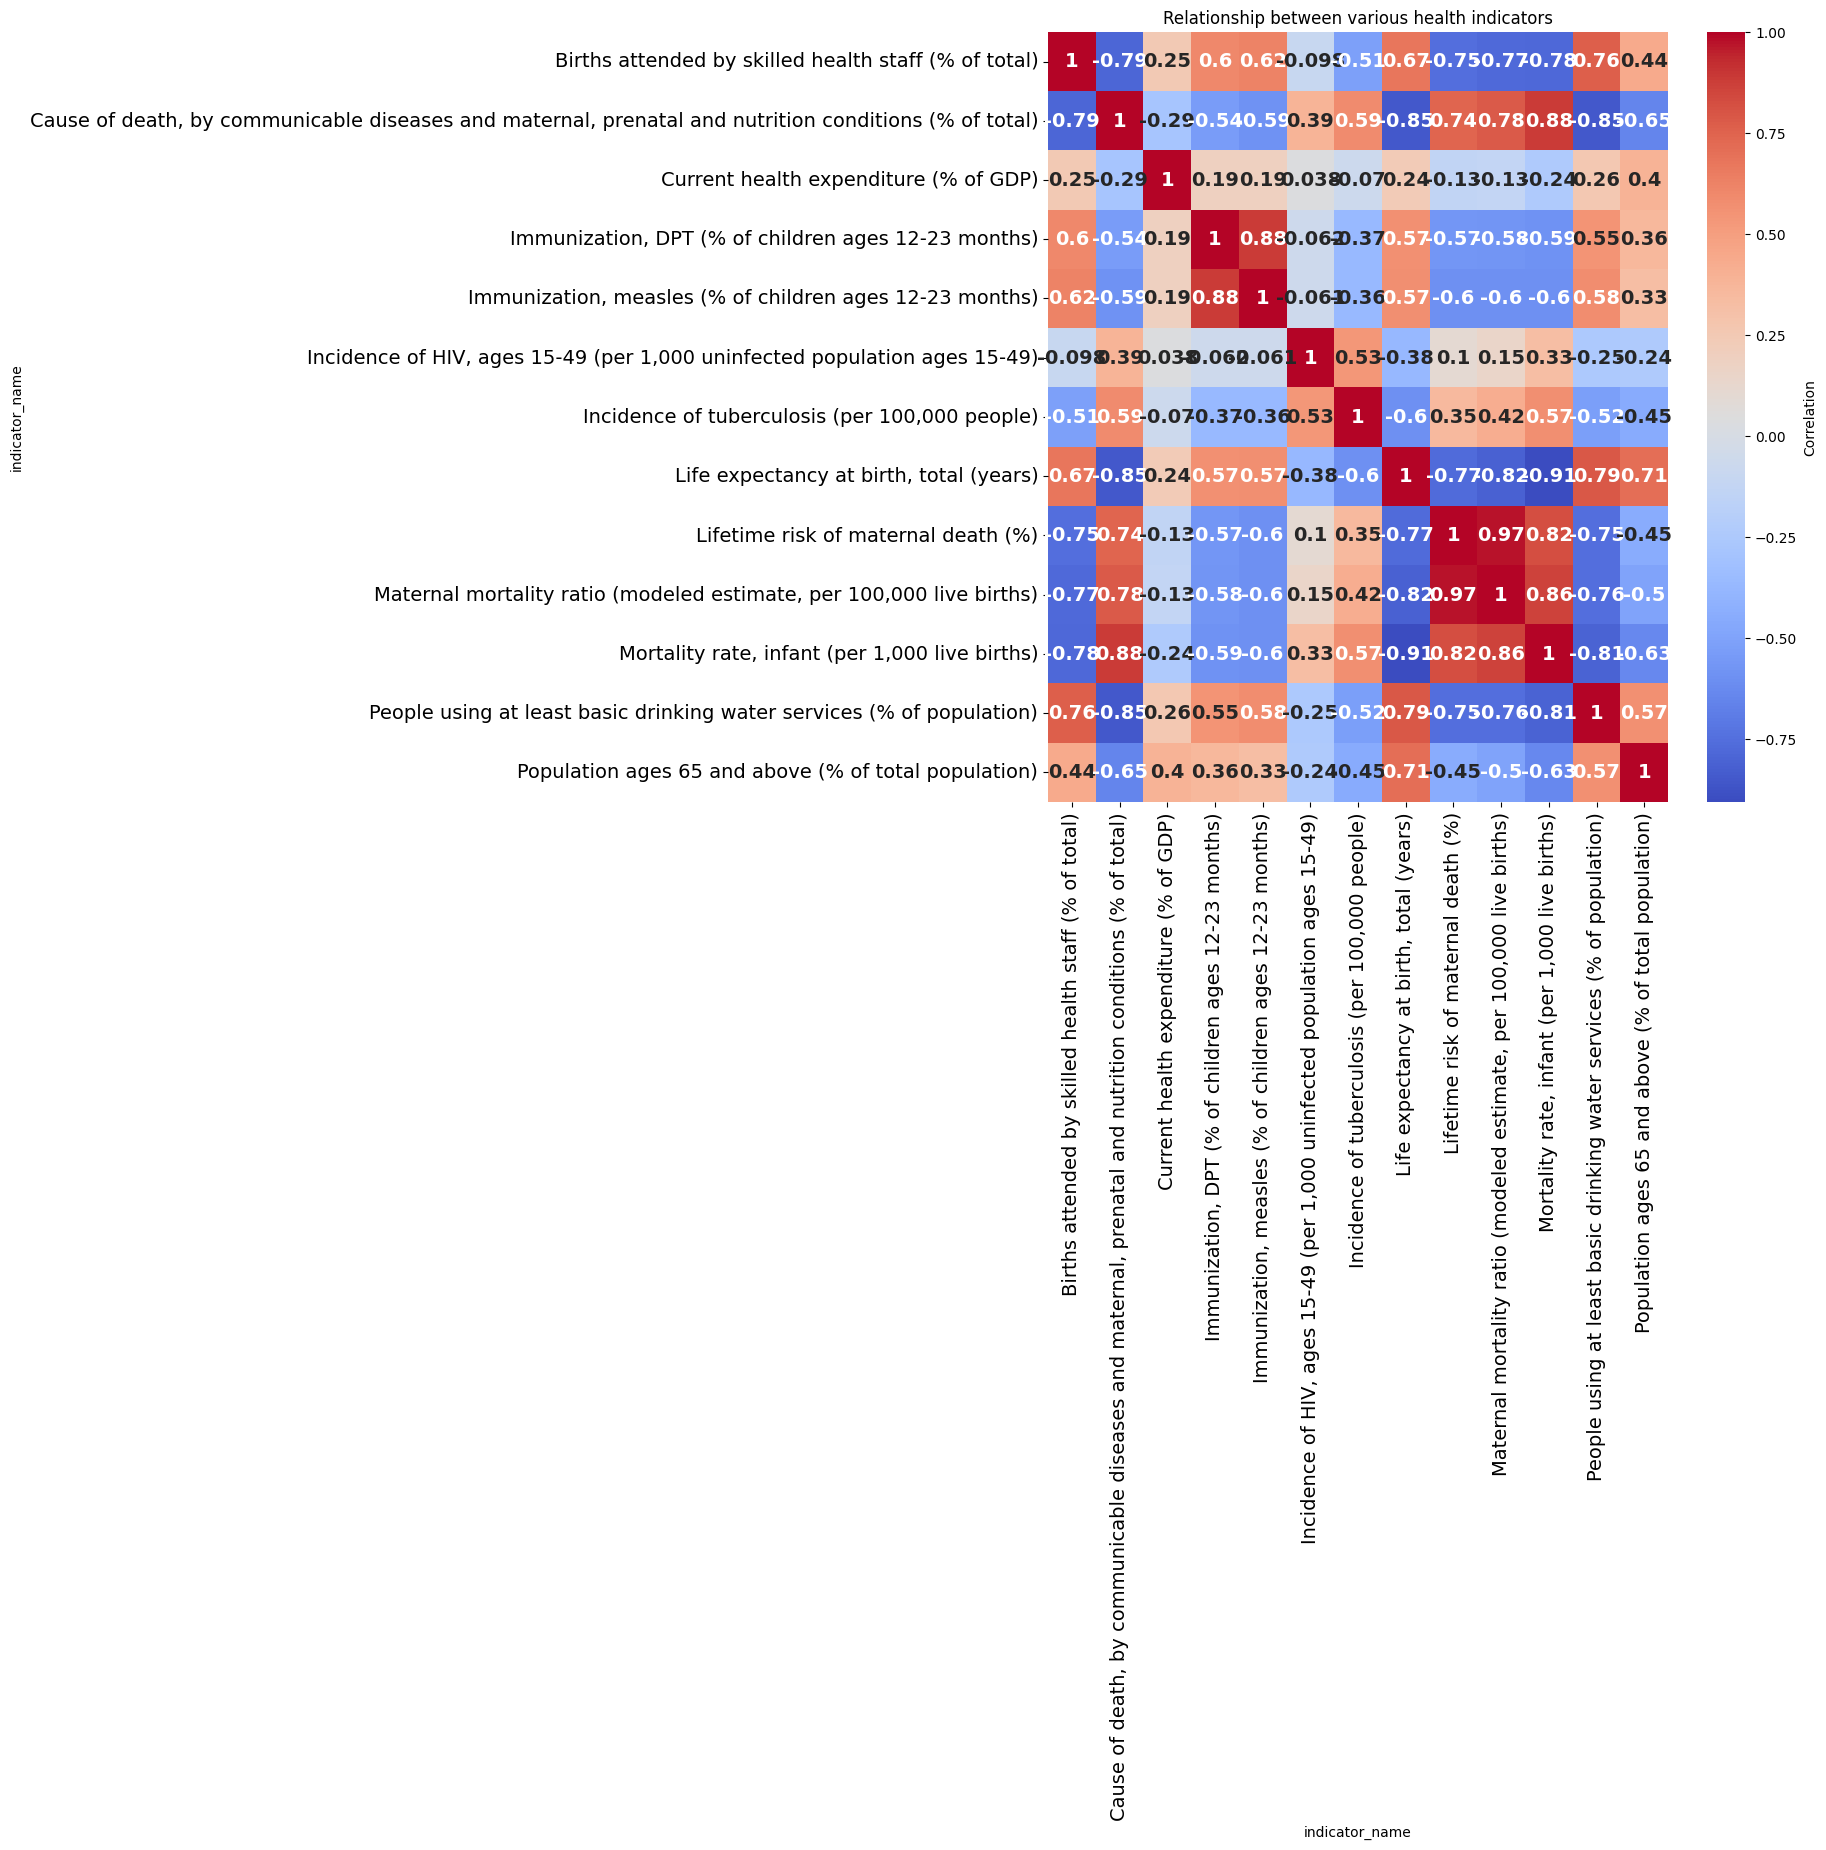

In [41]:
plt.figure(figsize=(10,10),facecolor ="none" )
ax=sns.heatmap(
            corr,
            annot=True,
            cmap= "coolwarm",
            cbar_kws= {"label":"Correlation"},
            annot_kws= {"fontsize" : 14 ,"fontweight":"bold"}
)
          
plt.title("Relationship between various health indicators")
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.show()